# Oumi - Compare an LLM Judge Against a Rule-Based GRPO Reward

<a target="_blank" href="https://colab.research.google.com/github/oumi-ai/oumi/blob/main/notebooks/Oumi%20-%20Compare%20LLM%20Judge%20vs%20Rule%20Reward.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Before swapping an LLM judge in as a GRPO reward, you want to know how it behaves relative to the
reward you already trust. This notebook uses the **letter-counting** task as a testbed, because it has
an exact rule-based reward (`count_letters_verl`, the one the verl GRPO trainer uses) to compare against.

The notebook:

1. Loads validation prompts from `oumi-ai/oumi-letter-count`.
2. Samples several completions per prompt from a policy model (a GRPO "group").
3. Scores every completion twice: with `count_letters_verl` and with your judge.
4. Compares them at three levels that matter for GRPO:
   * **Per-sample agreement** - does the judge score correlate with the rule reward?
   * **Within-group ranking** - GRPO normalizes advantages *inside* each prompt's group of completions,
     so what matters is whether the judge ranks siblings the same way the rule does.
   * **Zero-advantage groups** - if the judge gives every sibling the same score, that group produces no
     gradient. How often does that happen compared to the rule?
5. Surfaces the concrete disagreements so you can read the judge's reasoning.

Results are cached to disk after each stage, so you can re-run the judge (or try several judges) without
regenerating completions.

## Prerequisites

Install Oumi with GPU inference support (the policy model is served locally with vLLM):

```bash
pip install "oumi[gpu]"
```

If your judge uses a remote API, export its key (e.g. `OPENAI_API_KEY`) before starting the kernel.

## Configuration

Everything you are likely to change lives in this cell.

* `POLICY_MODEL` - the model whose completions get scored. Point it at a GRPO output directory to evaluate
  a trained checkpoint, or at a Hub model id for a base-model baseline.
* `JUDGE_CONFIG_PATH` - your judge's YAML (`JudgeConfig`). Its `prompt_template` may use any of the
  placeholders `{question}`, `{response}`, `{reference}`, `{word}`, `{letter}`. If you leave it as `None`,
  the notebook writes a simple reference-guided judge for you to adapt.
* `NUM_GENERATIONS` - completions sampled per prompt. This mirrors GRPO's group size, so match whatever
  `rollout.n` you plan to train with.

In [4]:
import os
from pathlib import Path

# Where generated completions, judge outputs, and the comparison table are saved.
tutorial_dir = Path("judge_vs_reward")
tutorial_dir.mkdir(parents=True, exist_ok=True)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

# Policy whose completions we score. The GRPO smoke run exports here; swap in
# "google/gemma-4-E2B-it" (or any HF id) to score the untrained base model instead.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# POLICY_MODEL = str(REPO_ROOT / "output/letter_counting/gemma4_e2b_grpo")
# POLICY_MODEL = "google/gemma-4-E2B-it"
POLICY_MODEL = str(
    REPO_ROOT
    / "output/letter_counting/grpo_verl_gemma4_e2b"
    / "batch64_pergpu16_rollout4/merged_step200"
)
POLICY_MODEL_NAME = "gemma-4-E3B-it-batch64_r4_merged_step200"
# POLICY_MODEL_NAME = Path(POLICY_MODEL).name

NUM_PROMPTS = 64  # validation prompts to sample
NUM_GENERATIONS = 4  # completions per prompt (the GRPO group size)
SAMPLING_TEMPERATURE = 1.0  # >0 so siblings differ; this is what GRPO rollouts use
MAX_NEW_TOKENS = 512

## 1. Load validation prompts

`LetterCountGrpoDataset` is the same dataset class the GRPO trainer uses. Each row carries the chat prompt
(system + user message), the integer ground truth, and the `reward_model.ground_truth` string that verl
passes to the reward function.

In [5]:
from oumi.datasets.grpo.letter_count import LetterCountGrpoDataset

dataset = LetterCountGrpoDataset(split="validation")

prompts = []
for idx in range(min(NUM_PROMPTS, len(dataset))):
    row = dataset[idx]
    raw = dataset.raw(idx)
    prompts.append(
        {
            "prompt_idx": idx,
            "messages": row["prompt"],
            "question": row["prompt"][-1]["content"],
            "word": raw["metadata"]["word"],
            "letter": raw["metadata"]["letter"],
            "ground_truth": row["reward_model"]["ground_truth"],  # str, as verl sees it
            "data_source": row["data_source"],
            "extra_info": row["extra_info"],
        }
    )

print(f"Loaded {len(prompts)} prompts. Example:")
print(prompts[0]["question"], "->", prompts[0]["ground_truth"])

[2026-09-01 12:10:25,702][oumi][rank0][pid:2182266][MainThread][INFO]][base_map_dataset.py:92] Creating map dataset (type: LetterCountGrpoDataset)... dataset_name: 'oumi-ai/oumi-letter-count'
[2026-09-01 12:10:28,668][oumi][rank0][pid:2182266][MainThread][INFO]][base_map_dataset.py:490] Dataset Info:
	Split: validation
	Version: 0.0.0
	Dataset size: 22894322
	Download size: 5697295
	Size: 28591617 bytes
	Rows: 10000
	Columns: ['conversation_id', 'messages', 'metadata']
[2026-09-01 12:10:29,031][oumi][rank0][pid:2182266][MainThread][INFO]][base_map_dataset.py:427] Loaded DataFrame with shape: (10000, 3). Columns:
conversation_id    object
messages           object
metadata           object
dtype: object
Loaded 64 prompts. Example:
Could you determine the count of 'l's in 'substantial'? -> 1


## 2. Sample completions from the policy

We replicate each prompt `NUM_GENERATIONS` times and sample with temperature, which is exactly what a GRPO
rollout does. Each `Conversation` carries its prompt index and generation index in `metadata` so we can
regroup later.

The completions are saved to `completions.jsonl`; re-running this cell loads them from disk instead of
regenerating. Delete the file to force regeneration.

In [8]:
import json

from oumi.core.configs import GenerationParams, ModelParams
from oumi.core.types.conversation import Conversation, Message, Role

completions_path = (
    tutorial_dir / f"policy_models_completions/completions_{POLICY_MODEL_NAME}.jsonl"
)

if completions_path.exists():
    with open(completions_path) as f:
        completed = [Conversation.from_json(line) for line in f]
    print(f"Loaded {len(completed)} cached completions from {completions_path}")
else:
    from oumi.inference import VLLMInferenceEngine

    conversations = []
    for p in prompts:
        for gen_idx in range(NUM_GENERATIONS):
            conversations.append(
                Conversation(
                    messages=[
                        Message(role=Role(m["role"]), content=m["content"])
                        for m in p["messages"]
                    ],
                    metadata={"prompt_idx": p["prompt_idx"], "gen_idx": gen_idx},
                )
            )

    engine = VLLMInferenceEngine(
        ModelParams(model_name=POLICY_MODEL, torch_dtype_str="bfloat16"),
        generation_params=GenerationParams(
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=SAMPLING_TEMPERATURE,
            top_p=1.0,
        ),
    )
    completed = engine.infer(conversations)

    with open(completions_path, "w") as f:
        for conv in completed:
            f.write(conv.to_json() + "\n")
    print(f"Generated {len(completed)} completions -> {completions_path}")

Loaded 256 cached completions from judge_vs_reward/policy_models_completions/completions_gemma-4-E3B-it-batch64_r4_merged_step200.jsonl


In [11]:
completed

[SYSTEM: Your final answer should be an integer written as digits and formatted as "\boxed{your_answer}". For example, if the answer is 42, you should output "\boxed{42}".
 USER: Could you determine the count of 'l's in 'substantial'?
 ASSISTANT: To find the count of the letter 'l' in the word 'substantial', we examine the word letter by letter:
 
 S - u - b - s - t - a - n - t - i - a - l
 
 Let's count the occurrences of 'l':
 1. s
 2. u
 3. b
 4. s
 5. t
 6. a
 7. n
 8. t
 9. i
 10. a
 11. l (Count = 1)
 
 There is only one 'l' in the word 'substantial'.
 
 $$\boxed{1}$$,
 SYSTEM: Your final answer should be an integer written as digits and formatted as "\boxed{your_answer}". For example, if the answer is 42, you should output "\boxed{42}".
 USER: Could you determine the count of 'l's in 'substantial'?
 ASSISTANT: To determine the count of the letter 'l' in the word 'substantial', we examine the word:
 s u b s t a n t i a l
 
 Let's count the occurrences of 'l':
 1. s
 2. u
 3. b
 4

## 3. Score with the rule-based reward

`count_letters_verl` is called with the same four arguments verl passes it. It parses a `\boxed{N}` answer
and returns `0.0` for an exact count, decaying towards `-2.0` as the count drifts, and `-3.0` when no
parseable answer exists. We also record the parsed prediction so we can see *why* a reward was low.

In [12]:
import pandas as pd

from oumi.core.types.conversation import Role
from oumi.datasets.grpo.rewards.count_letters_rewards import (
    _extract_prediction,
    count_letters_verl,
)

prompt_by_idx = {p["prompt_idx"]: p for p in prompts}
rows = []
for conv in completed:
    p = prompt_by_idx[conv.metadata["prompt_idx"]]
    response = conv.last_message(Role.ASSISTANT).content
    reward = count_letters_verl(
        data_source=p["data_source"],
        solution_str=response,
        ground_truth=p["ground_truth"],
        extra_info=p["extra_info"],
    )
    rows.append(
        {
            "prompt_idx": p["prompt_idx"],
            "gen_idx": conv.metadata["gen_idx"],
            "word": p["word"],
            "letter": p["letter"],
            "question": p["question"],
            "ground_truth": int(p["ground_truth"]),
            "predicted": _extract_prediction(response),
            "response": response,
            "rule_reward": reward,
            "rule_correct": reward == 0.0,
        }
    )

df = pd.DataFrame(rows).sort_values(["prompt_idx", "gen_idx"]).reset_index(drop=True)

print(f"Mean rule reward: {df.rule_reward.mean():.3f}")
print(f"Exact-match accuracy: {df.rule_correct.mean():.1%}")
print(f"Unparseable (no \\boxed{{}}): {df.predicted.isna().mean():.1%}")
df[["word", "letter", "ground_truth", "predicted", "rule_reward"]].head(8)

Mean rule reward: -0.573
Exact-match accuracy: 80.5%
Unparseable (no \boxed{}): 18.8%


,word,letter,ground_truth,predicted,rule_reward
0,substantial,l,1,1.0,0.0
1,substantial,l,1,1.0,0.0
2,substantial,l,1,NaN,-3.0
3,substantial,l,1,1.0,0.0
4,semibeam,u,0,0.0,0.0
5,semibeam,u,0,0.0,0.0
6,semibeam,u,0,0.0,0.0
7,semibeam,u,0,0.0,0.0


In [13]:
cols = ["word", "letter", "ground_truth", "predicted", "rule_reward"]
df.loc[df["rule_reward"] != 0.0, cols]

,word,letter,ground_truth,predicted,rule_reward
2,substantial,l,1,NaN,-3.000000
15,subclimatic,t,1,NaN,-3.000000
24,narcomania,n,2,NaN,-3.000000
25,narcomania,n,2,NaN,-3.000000
26,narcomania,n,2,NaN,-3.000000
27,narcomania,n,2,NaN,-3.000000
30,interlopers,o,1,NaN,-3.000000
37,circumscissile,r,1,NaN,-3.000000
38,circumscissile,r,1,NaN,-3.000000
39,circumscissile,r,1,NaN,-3.000000


## 4. Score with the LLM judge

If you did not set `JUDGE_CONFIG_PATH`, the cell below writes a starter judge. It is **reference-guided**
(it sees the true count) and asks for a 0-10 correctness score rather than a Yes/No, because GRPO needs
the judge to *rank* siblings - a binary judge produces many all-equal groups with zero advantage.

The judge is applied through `SimpleJudge`, exactly as the `conversation_llm_judge` reward does. Any
placeholders your template uses are filled from the columns of `df` plus `reference` (= ground truth).

In [14]:
from dotenv import load_dotenv

load_dotenv()

True

In [17]:
system_prompt_2 = r"""
You are a reward judge for a letter-counting task. Your score will be
used directly as the reward signal for reinforcement learning, so you
must apply the rules below exactly and deterministically. Identical
inputs must always receive identical scores.

INPUTS
You will receive:
<target>the correct letter count (an integer)</target>
<response>the model's full response</response>

STEP 1 — Extraction (Essential Criteria)
Determine whether the response contains EXACTLY ONE final answer in the
form \boxed{N}, where N is an integer (optionally signed).
The following all make a response UNPARSEABLE:
- No \boxed{...} at all (Pitfall: an answer stated only in prose, e.g.
  "the answer is 7", does NOT count)
- More than one \boxed{...} (Pitfall: even if they agree)
- \boxed{...} containing anything other than a plain integer, e.g.
  \boxed{7.0}, \boxed{seven}, \boxed{7 letters}
Do NOT count letters yourself. Do NOT judge reasoning quality, length,
or style. Never infer or repair a malformed answer.

STEP 2 — Scoring
If UNPARSEABLE: score is -3.0. This is the unique lowest score.
Otherwise compute delta = |extracted N - target| and read the score
from this table (do not derive it yourself):
  delta 0  -> 0.0
  delta 1  -> -1.33
  delta 2  -> -1.6
  delta 3  -> -1.71
  delta 4  -> -1.78
  delta 5  -> -1.82
  delta 6  -> -1.85
  delta 7  -> -1.87
  delta 8  -> -1.88
  delta 9  -> -1.89
  delta 10 or more -> -1.9

In your explanation, state the extracted N (or why extraction failed)
and the delta.
"""


PROMPT_TEMPLATE_2 = """\
<target>{reference}</target>
<response>{response}</response>
"""

In [18]:
# Your judge. Set to a path to use an existing JudgeConfig YAML.
JUDGE_CONFIG_PATH = tutorial_dir / "letter_count_judge_v2.yaml"  # None

# Overrides for the starter judge written in section 4 (ignored if
# JUDGE_CONFIG_PATH points at your own YAML). Leave as None for the defaults;
# set JUDGE_SYSTEM_INSTRUCTION to any string (e.g. system_prompt_2) to swap
# in different grading instructions.
JUDGE_SYSTEM_INSTRUCTION = system_prompt_2  # None
JUDGE_PROMPT_TEMPLATE = None

In [ ]:
DEFAULT_SYSTEM_INSTRUCTION = """\
You are grading answers to letter-counting questions. You will be shown the
question, the model's response, and the correct count. Score the response
from 0 to 10:
  10 - the final answer is exactly the correct count.
   5 - the final answer is off by one.
   2 - the final answer is off by two or more.
   0 - the response gives no clear final answer.
Judge only the final numeric answer, not the reasoning or formatting.
"""

DEFAULT_PROMPT_TEMPLATE = """\
[question]:
{question}

[response]:
{response}

[correct count]:
{reference}
"""

In [27]:
import yaml


# Render multi-line strings as YAML block scalars (|) for readability.
def _str_representer(dumper, value):
    style = "|" if "\n" in value else None
    return dumper.represent_scalar("tag:yaml.org,2002:str", value, style=style)


yaml.SafeDumper.add_representer(str, _str_representer)


judge_config = {
    "judge_params": {
        "system_instruction": system_prompt_2,
        "prompt_template": PROMPT_TEMPLATE_2,
        "response_format": "JSON",
        "judgment_type": "FLOAT",  # "INT",
        "include_explanation": True,
    },
    "inference_config": {
        "model": {"model_name": "gpt-4o-mini"},  # {"model_name": "gpt-4o"},
        "engine": "OPENAI",
        "generation": {"max_new_tokens": 512, "temperature": 0.0},
    },
}
JUDGE_CONFIG_PATH.write_text(yaml.safe_dump(judge_config, sort_keys=False))
print(f"Wrote starter judge config to {JUDGE_CONFIG_PATH}")

print(Path(JUDGE_CONFIG_PATH).read_text())

Wrote starter judge config to judge_vs_reward/letter_count_judge_v2.yaml
judge_params:
  system_instruction: "\nYou are a reward judge for a letter-counting task. Your score\
    \ will be\nused directly as the reward signal for reinforcement learning, so you\n\
    must apply the rules below exactly and deterministically. Identical\ninputs must\
    \ always receive identical scores.\n\nINPUTS\nYou will receive:\n<target>the correct\
    \ letter count (an integer)</target>\n<response>the model's full response</response>\n\
    \nSTEP 1 \u2014 Extraction (Essential Criteria)\nDetermine whether the response\
    \ contains EXACTLY ONE final answer in the\nform \\boxed{N}, where N is an integer\
    \ (optionally signed).\nThe following all make a response UNPARSEABLE:\n- No \\\
    boxed{...} at all (Pitfall: an answer stated only in prose, e.g.\n  \"the answer\
    \ is 7\", does NOT count)\n- More than one \\boxed{...} (Pitfall: even if they\
    \ agree)\n- \\boxed{...} containing a

In [28]:
from oumi.judges.simple_judge import SimpleJudge

judge_outputs_path = tutorial_dir / "judge_v2_outputs_gpt4omini.jsonl"

judge = SimpleJudge(str(JUDGE_CONFIG_PATH))

judge_inputs = [
    {
        "question": r.question,
        "response": r.response,
        "reference": str(r.ground_truth),
        "word": r.word,
        "letter": r.letter,
    }
    for r in df.itertuples()
]

if judge_outputs_path.exists():
    with open(judge_outputs_path) as f:
        judge_records = [json.loads(line) for line in f]
    assert len(judge_records) == len(df), (
        "Cached judge outputs don't match df; delete the file."
    )
    print(f"Loaded {len(judge_records)} cached judge outputs")
else:
    outputs = judge.judge(judge_inputs)
    judge_records = []
    for out in outputs:
        # Prefer the numeric score mapping (BOOL/ENUM); fall back to the
        # typed value (INT/FLOAT).
        score = (out.field_scores or {}).get("judgment")
        if score is None:
            value = (out.field_values or {}).get("judgment")
            score = float(value) if isinstance(value, (int, float, bool)) else None
        judge_records.append(
            {
                "judge_score": score,
                "judge_explanation": (out.field_values or {}).get("explanation"),
                "judge_raw": out.raw_output,
            }
        )
    with open(judge_outputs_path, "w") as f:
        for rec in judge_records:
            f.write(json.dumps(rec) + "\n")
    print(f"Judged {len(judge_records)} completions -> {judge_outputs_path}")

df["judge_score"] = [r["judge_score"] for r in judge_records]
df["judge_explanation"] = [r["judge_explanation"] for r in judge_records]

n_failed = df.judge_score.isna().sum()
if n_failed:
    print(
        f"WARNING: judge returned no parseable score for {n_failed} "
        "completions; they are excluded below."
    )
df_ok = df.dropna(subset=["judge_score"]).copy()

# # A "judge says correct" flag, defined as the judge's maximum possible score.
# judge_max = df_ok.judge_score.max()
# A "judge says correct" flag, defined as the judge's maximum score
judge_max = 0  # 10
df_ok["judge_correct"] = df_ok.judge_score == judge_max
df_ok[
    ["word", "letter", "ground_truth", "predicted", "rule_reward", "judge_score"]
].head(8)

  0%|          | 0/256 [00:00<?, ?it/s]

100%|██████████| 256/256 [04:09<00:00,  1.03it/s]

Judged 256 completions -> judge_vs_reward/judge_v2_outputs_gpt4omini.jsonl


,word,letter,ground_truth,predicted,rule_reward,judge_score
0,substantial,l,1,1.0,0.0,0.0
1,substantial,l,1,1.0,0.0,0.0
2,substantial,l,1,NaN,-3.0,-3.0
3,substantial,l,1,1.0,0.0,0.0
4,semibeam,u,0,0.0,0.0,0.0
5,semibeam,u,0,0.0,0.0,0.0
6,semibeam,u,0,0.0,0.0,0.0
7,semibeam,u,0,0.0,0.0,0.0


## 5. Per-sample agreement

First the coarse picture: how does the judge's score move with the rule reward?

* **Spearman** measures monotonic agreement (does higher rule reward mean higher judge score?).
* **Pearson** measures linear agreement; less relevant here since the two scales differ.
* The **confusion matrix** treats the judge's top score as "correct" and compares it to exact-match.
  Off-diagonal cells are where the judge would push the policy in the wrong direction.

In [29]:
from scipy import stats

spearman = stats.spearmanr(df_ok.rule_reward, df_ok.judge_score)
pearson = stats.pearsonr(df_ok.rule_reward, df_ok.judge_score)
print(f"Spearman rho = {spearman.statistic:.3f}  (p={spearman.pvalue:.2g})")
print(f"Pearson  r   = {pearson.statistic:.3f}  (p={pearson.pvalue:.2g})")

confusion = pd.crosstab(
    df_ok.rule_correct.map({True: "rule: correct", False: "rule: incorrect"}),
    df_ok.judge_correct.map({True: "judge: correct", False: "judge: incorrect"}),
)
print()
print(confusion)

tp = int((df_ok.rule_correct & df_ok.judge_correct).sum())
fp = int((~df_ok.rule_correct & df_ok.judge_correct).sum())
fn = int((df_ok.rule_correct & ~df_ok.judge_correct).sum())
precision = tp / (tp + fp) if tp + fp else float("nan")
recall = tp / (tp + fn) if tp + fn else float("nan")
print(f"\nJudge precision vs ground truth: {precision:.1%}   recall: {recall:.1%}")
print(f"Judge false positives (rewards a wrong answer): {fp}")
print(f"Judge false negatives (penalizes a right answer): {fn}")

Spearman rho = 0.924  (p=9.2e-108)
Pearson  r   = 0.922  (p=6.8e-107)

judge_correct    judge: correct  judge: incorrect
rule_correct                                     
rule: correct               206                 0
rule: incorrect               6                44

Judge precision vs ground truth: 97.2%   recall: 100.0%
Judge false positives (rewards a wrong answer): 6
Judge false negatives (penalizes a right answer): 0


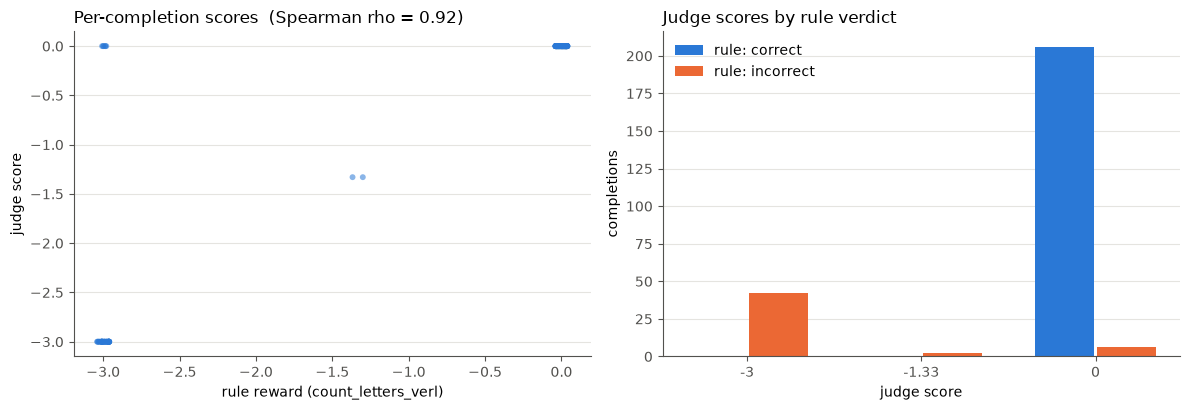

In [30]:
import matplotlib.pyplot as plt

SERIES_1, SERIES_2 = "#2a78d6", "#eb6834"  # fixed categorical hues
TEXT_2 = "#52514e"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: every completion, jittered so overlapping points stay visible.
ax = axes[0]
rng = __import__("numpy").random.default_rng(0)
jitter = rng.uniform(-0.04, 0.04, size=len(df_ok))
ax.scatter(
    df_ok.rule_reward + jitter,
    df_ok.judge_score + jitter * (judge_max / 3),
    s=18,
    color=SERIES_1,
    alpha=0.55,
    edgecolors="none",
)
ax.set_xlabel("rule reward (count_letters_verl)")
ax.set_ylabel("judge score")
ax.set_title(
    f"Per-completion scores  (Spearman rho = {spearman.statistic:.2f})", loc="left"
)

# Right: judge score distribution split by whether the rule says the answer is right.
ax = axes[1]
score_values = sorted(df_ok.judge_score.unique())
for label, color, mask, offset in [
    ("rule: correct", SERIES_1, df_ok.rule_correct, -0.18),
    ("rule: incorrect", SERIES_2, ~df_ok.rule_correct, 0.18),
]:
    counts = df_ok[mask].judge_score.value_counts().reindex(score_values, fill_value=0)
    ax.bar(
        [i + offset for i in range(len(score_values))],
        counts.values,
        width=0.34,
        color=color,
        label=label,
        linewidth=0,
    )
ax.set_xticks(range(len(score_values)))
ax.set_xticklabels([f"{v:g}" for v in score_values])
ax.set_xlabel("judge score")
ax.set_ylabel("completions")
ax.set_title("Judge scores by rule verdict", loc="left")
ax.legend(frameon=False)

for ax in axes:
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color(TEXT_2)
    ax.spines["bottom"].set_color(TEXT_2)
    ax.tick_params(colors=TEXT_2)
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 6. Within-group ranking (what GRPO actually uses)

GRPO computes each completion's advantage as its reward minus the mean reward *of its own group*, divided
by the group's standard deviation. Two consequences:

* Only the **ordering within a group** matters. A judge that is miscalibrated in absolute terms but ranks
  siblings correctly trains the policy identically to the rule.
* A group where every sibling gets the **same score** has zero advantage everywhere and contributes no
  gradient. A judge that flattens distinctions the rule would make throws away training signal.

For each prompt we compute Kendall's tau between the rule and judge rankings of its `NUM_GENERATIONS`
completions, whether each scorer produced a constant (zero-advantage) group, and whether the judge's
top-ranked completion is one the rule marks correct.

In [31]:
import numpy as np


def group_stats(g: pd.DataFrame) -> pd.Series:
    """Summarize rule-vs-judge ranking agreement within one GRPO group."""
    rule_const = (g.rule_reward == g.rule_reward.iloc[0]).all()
    judge_const = (g.judge_score == g.judge_score.iloc[0]).all()
    if rule_const or judge_const or len(g) < 2:
        tau = np.nan  # undefined when either scorer is flat
    else:
        tau = stats.kendalltau(g.rule_reward, g.judge_score).statistic
    judge_top = g.loc[g.judge_score.idxmax()]
    return pd.Series(
        {
            "n": len(g),
            "kendall_tau": tau,
            "rule_constant": rule_const,
            "judge_constant": judge_const,
            "any_rule_correct": g.rule_correct.any(),
            # Is the judge's top-ranked completion actually correct
            # according to the ground truth?
            "judge_top_is_correct": bool(judge_top.rule_correct),
        }
    )


groups = df_ok.groupby("prompt_idx").apply(group_stats, include_groups=False)

informative = groups[
    ~groups.rule_constant & ~groups.judge_constant
]  # groups where both scorers vary enough to compare rankings
print(f"Groups: {len(groups)}   (size {NUM_GENERATIONS})")
print(f"Zero-advantage groups under the RULE:  {groups.rule_constant.mean():.1%}")
print(f"Zero-advantage groups under the JUDGE: {groups.judge_constant.mean():.1%}")
print(
    "Groups the rule can learn from but the judge flattens: "
    f"{(~groups.rule_constant & groups.judge_constant).sum()}"
)
print()
print(
    f"Mean within-group Kendall tau (both non-constant, n={len(informative)}): "
    f"{informative.kendall_tau.mean():.3f}"
)
print(
    "Groups with perfect rank agreement (tau = 1): "
    f"{(informative.kendall_tau == 1).mean():.1%}"
)
print(
    "Groups with rank reversals (tau < 0):         "
    f"{(informative.kendall_tau < 0).mean():.1%}"
)

learnable = groups[groups.any_rule_correct]
print()
print(
    "When a group contains at least one correct answer, "
    "the judge's favourite is correct "
    f"{learnable.judge_top_is_correct.mean():.1%} of the time (n={len(learnable)})."
)

Groups: 64   (size 4)
Zero-advantage groups under the RULE:  53.1%
Zero-advantage groups under the JUDGE: 56.2%
Groups the rule can learn from but the judge flattens: 2

Mean within-group Kendall tau (both non-constant, n=28): 0.955
Groups with perfect rank agreement (tau = 1): 89.3%
Groups with rank reversals (tau < 0):         0.0%

When a group contains at least one correct answer, the judge's favourite is correct 96.8% of the time (n=62).


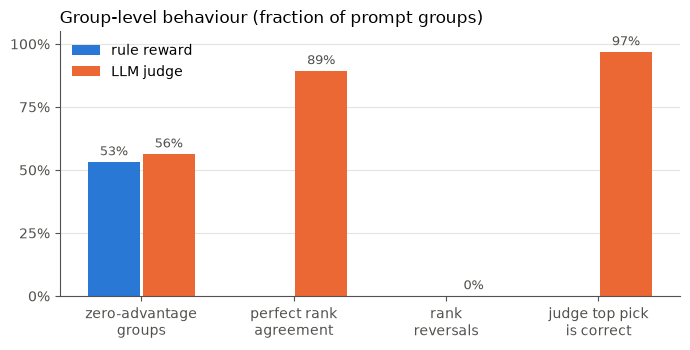

In [32]:
fig, ax = plt.subplots(figsize=(7, 3.6))

labels = [
    "zero-advantage\ngroups",
    "perfect rank\nagreement",
    "rank\nreversals",
    "judge top pick\nis correct",
]
rule_vals = [groups.rule_constant.mean(), np.nan, np.nan, np.nan]
judge_vals = [
    groups.judge_constant.mean(),
    (informative.kendall_tau == 1).mean() if len(informative) else np.nan,
    (informative.kendall_tau < 0).mean() if len(informative) else np.nan,
    learnable.judge_top_is_correct.mean() if len(learnable) else np.nan,
]
x = np.arange(len(labels))
ax.bar(
    x - 0.18, rule_vals, width=0.34, color=SERIES_1, label="rule reward", linewidth=0
)
ax.bar(x + 0.18, judge_vals, width=0.34, color=SERIES_2, label="LLM judge", linewidth=0)
for xi, v in zip(x + 0.18, judge_vals):
    if not np.isnan(v):
        ax.text(
            xi,
            v + 0.015,
            f"{v:.0%}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=TEXT_2,
        )
ax.text(
    x[0] - 0.18,
    rule_vals[0] + 0.015,
    f"{rule_vals[0]:.0%}",
    ha="center",
    va="bottom",
    fontsize=9,
    color=TEXT_2,
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_title("Group-level behaviour (fraction of prompt groups)", loc="left")
ax.legend(frameon=False)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color(TEXT_2)
ax.spines["bottom"].set_color(TEXT_2)
ax.tick_params(colors=TEXT_2)
ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 7. Read the disagreements

Numbers tell you *how much* the judge disagrees; the examples tell you *why*. The cell below lists the
completions where the two scorers disagree about correctness, alongside the judge's explanation.
Typical things to look for:

* **Judge rewards a wrong answer** - is it being fooled by confident reasoning, or misreading `\boxed{}`?
* **Judge penalizes a right answer** - is it grading formatting or verbosity instead of the answer?
* **Parsing gaps** - the rule gives `-3.0` to anything without `\boxed{N}`; does the judge extract answers
  the rule misses? That is a legitimate case where the judge might be *better* than the rule.

In [33]:
pd.set_option("display.max_colwidth", 160)

disagree = df_ok[df_ok.rule_correct != df_ok.judge_correct].copy()
disagree["kind"] = np.where(
    disagree.judge_correct, "judge rewards WRONG answer", "judge penalizes RIGHT answer"
)
disagree["response_tail"] = disagree.response.str[-140:]

print(f"{len(disagree)} disagreements out of {len(df_ok)} completions")
disagree[
    [
        "kind",
        "word",
        "letter",
        "ground_truth",
        "predicted",
        "rule_reward",
        "judge_score",
        "response_tail",
        "judge_explanation",
    ]
].sort_values("kind").head(20)

6 disagreements out of 256 completions


,kind,word,letter,ground_truth,predicted,rule_reward,judge_score,response_tail,judge_explanation
65,judge rewards WRONG answer,unsightedly,u,1,NaN,-3.0,0.0,ven: 'unsightedly'.\n\nU N S I G H T E D L Y\nCount of 'u' = 1.\n\nLet's search for common misspellings or if 'unsightedly' is meant to have more,"The response contains a final answer in the form \boxed{1}, which is correctly formatted. The extracted N is 1. The target is also 1, so the delta is |1 - 1..."
114,judge rewards WRONG answer,arrhenal,a,2,NaN,-3.0,0.0,l\n\nLet's count the 'a's:\n1. a (first letter)\n2. r\n3. r\n4. h\n5. e\n6. n\n7. a (seventh letter)\n8. l\n\nThere are 2 'a's in the word 'arrhenal'.\n\n,"The response contains the final answer in the form \boxed{2}, which is a valid extraction. The extracted N is 2. The target is also 2, so the delta is |2 - ..."
115,judge rewards WRONG answer,arrhenal,a,2,NaN,-3.0,0.0,fth letter is 'e'.\n6. The sixth letter is 'n'.\n7. The seventh letter is 'a'.\n8. The eighth letter is 'l'.\n\nThe letter 'a' appears 2 times.\n\n,"The response contains a final answer in the form \boxed{2}, which is a plain integer. The extracted N is 2. The target is also 2, so the delta is |2 - 2| = 0."
135,judge rewards WRONG answer,preseparation,n,1,NaN,-3.0,0.0,e\n4. s\n5. e\n6. p\n7. a\n8. r\n9. a\n10. t\n11. i\n12. o\n13. n (Count = 1)\n\nThe letter 'n' appears once in the word 'preseparation'.\n\n$\square{1}$,"The response contains a final answer in the form \boxed{1}, which is a plain integer. The extracted N is 1. The target is also 1, so the delta is |1 - 1| = 0."
169,judge rewards WRONG answer,overfacility,i,2,NaN,-3.0,0.0,\n4. r\n5. f\n6. a\n7. c\n8. **i** (Count: 1)\n9. l\n10. **i** (Count: 2)\n11. t\n12. y\n\nThe letter 'i' appears 2 times in the word 'overfacility'.\n\n,"The response contains a final answer in the form \boxed{2}, which is correctly formatted. The extracted N is 2. The target is also 2, so the delta is |2 - 2..."
228,judge rewards WRONG answer,unconscious,u,2,NaN,-3.0,0.0,"in ""unconscious"":\nu - 1\nn\nc\no\nn\ns\nc\ni\no\nu - 2\ns\n\nThe 'u's appear at the first position and the eighth position.\nTotal count of 'u's is 2.\n\n","The response contains the final answer in the form \boxed{2}. The extracted N is 2. The target is also 2, so the delta is |2 - 2| = 0."


### Cases where the rule could not parse an answer

These got the minimum rule reward (`-3.0`). If the judge scores some of them highly, inspect whether the
model actually answered correctly in a format the regex does not recognize - that is a reward-design
finding about the *rule*, not the judge.

In [26]:
unparsed = df_ok[df_ok.predicted.isna()]
print(f"{len(unparsed)} completions had no parseable \\boxed{{N}}")
if len(unparsed):
    print("Judge score distribution on those:")
    print(unparsed.judge_score.value_counts().sort_index())
    unparsed = unparsed.assign(response_tail=unparsed.response.str[-140:])
    display(
        unparsed[
            [
                "word",
                "letter",
                "ground_truth",
                "judge_score",
                "response_tail",
                "judge_explanation",
            ]
        ].head(10)
    )

48 completions had no parseable \boxed{N}
Judge score distribution on those:
judge_score
-3.0    47
 0.0     1
Name: count, dtype: int64


,word,letter,ground_truth,judge_score,response_tail,judge_explanation
2,substantial,l,1,-3.0,l':\ns u b s t a n t i a l\n\n1. s\n2. u\n3. b\n4. s\n5. t\n6. a\n7. n\n8. t\n9. i\n10. a\n11. l (1st 'l')\n\nThere is one 'l' in the word 'substantial'.\n\n,"The response does not contain any \boxed{...} format to indicate the final answer. Therefore, it is unparseable."
15,subclimatic,t,1,-3.0,"a t i c\n\n1. s\n2. u\n3. b\n4. c\n5. l\n6. i\n7. m\n8. a\n9. t (1st occurrence)\n10. i\n11. c\n\nThe letter 't' appears once in the word ""subclimatic"".\n\n","The response does not contain any \boxed{...} format to indicate a final answer. Therefore, it is unparseable."
24,narcomania,n,2,-3.0,*n** (1st letter)\n2. a\n3. r\n4. c\n5. o\n6. m\n7. a\n8. **n** (8th letter)\n9. i\n10. a\n\nThe letter 'n' appears 2 times in the word 'narcomania'.\n\n,"The response does not contain any \boxed{...} format to indicate a final answer. Therefore, it is unparseable."
25,narcomania,n,2,-3.0,first letter)\n2. a\n3. r\n4. c\n5. o\n6. m\n7. a\n8. **n** (seventh letter)\n9. i\n10. a\n\nThe letter 'n' appears 2 times in the word 'narcomania'.\n\n,"The response does not contain any \boxed{...} format to indicate a final answer. Therefore, it is unparseable."
26,narcomania,n,2,-3.0,(first letter)\n2. a\n3. r\n4. c\n5. o\n6. m\n7. a\n8. **n** (eighth letter)\n9. i\n10. a\n\nThe letter 'n' appears 2 times in the word 'narcomania'.\n\n,"The response does not contain any \boxed{...} format to indicate a final answer. Therefore, it is unparseable."
27,narcomania,n,2,-3.0,1. **n** (first letter)\n2. a\n3. r\n4. c\n5. o\n6. m\n7. a\n8. **n** (eighth letter)\n9. i\n10. a\n\nThe letter 'n' appears 2 times in 'narcomania'.\n\n,"The response does not contain any \boxed{...} format to indicate a final answer. Therefore, it is unparseable."
30,interlopers,o,1,-3.0,itions 5 and 10)\nl - 1\n**o** - 1 (at position 7)\np - 1\ns - 1\n\nThe word is: i n t e r l **o** p e r s\n\nThe letter 'o' appears exactly once.\n\n,"The response does not contain any \boxed{...} format to indicate a final answer. Therefore, it is unparseable according to the criteria."
37,circumscissile,r,1,-3.0,(Count = 1)\n4. c\n5. u\n6. m\n7. s\n8. c\n9. i\n10. s\n11. s\n12. i\n13. l\n14. e\n\nThe letter 'r' appears exactly once in the word 'circumscissile'.\n\n,"The response does not contain any \boxed{...} format to extract a final answer. Therefore, it is unparseable."
38,circumscissile,r,1,-3.0,occurrence)\n4. c\n5. u\n6. m\n7. s\n8. c\n9. i\n10. s\n11. s\n12. i\n13. l\n14. e\n\nThe letter 'r' appears exactly once in the word 'circumscissile'.\n\n,"The response does not contain any \boxed{...} format to extract a final answer. Therefore, it is unparseable."
39,circumscissile,r,1,-3.0,. **r** (1)\n4. c\n5. u\n6. m\n7. s\n8. c\n9. i\n10. s\n11. s\n12. i\n13. l\n14. e\n\nThe letter 'r' appears exactly once in the word 'circumscissile'.\n\n,"The response does not contain any \boxed{...} format to extract a final answer. Therefore, it is unparseable."


## 8. Save the comparison table

The full per-completion table is written to CSV so you can dig further, share it, or diff against a run
with a different judge. To compare judges, point `JUDGE_CONFIG_PATH` at another YAML, delete
`judge_outputs.jsonl`, and re-run from section 4 - the completions are reused.

In [ ]:
out_csv = tutorial_dir / "judge_vs_rule_comparison.csv"
df.to_csv(out_csv, index=False)
groups.to_csv(tutorial_dir / "group_stats.csv")
print(f"Saved {len(df)} rows -> {out_csv}")
print(f"Saved {len(groups)} group rows -> {tutorial_dir / 'group_stats.csv'}")

## Reading the results

A judge is a safe drop-in replacement for the rule when, on this task:

* within-group Kendall tau is high (≳0.8) and rank reversals are rare,
* it does not create many more zero-advantage groups than the rule,
* its top pick in a group is almost always a rule-correct completion, and
* the disagreements are dominated by cases where the *rule* is at fault (unparsed but correct answers).

If the judge fails these on a task with a known answer, it will fail silently on a task without one. The
usual fixes are a graded (not binary) scale, giving the judge the reference answer, `temperature: 0`, and
telling it explicitly what *not* to grade (length, style, formatting).

Once you are happy, the same `SimpleJudge` call becomes a verl reward function: see the
`conversation_llm_judge` pattern in `src/oumi/datasets/grpo/rewards/` and register your judge reward
alongside `count_letters_verl`.